# Day 57 — ColumnTransformer

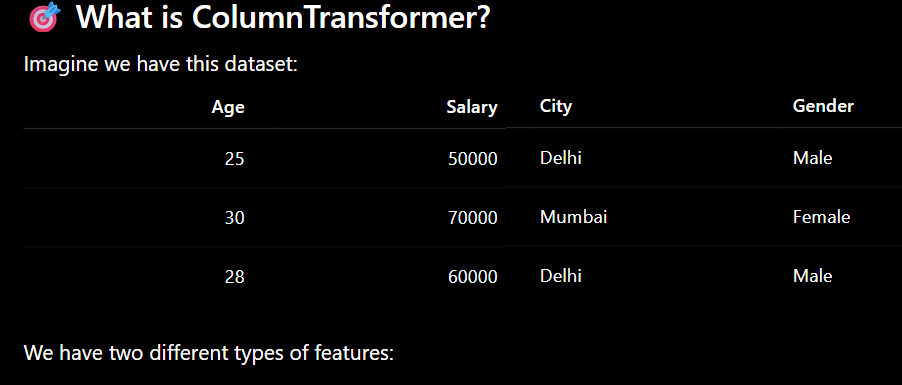
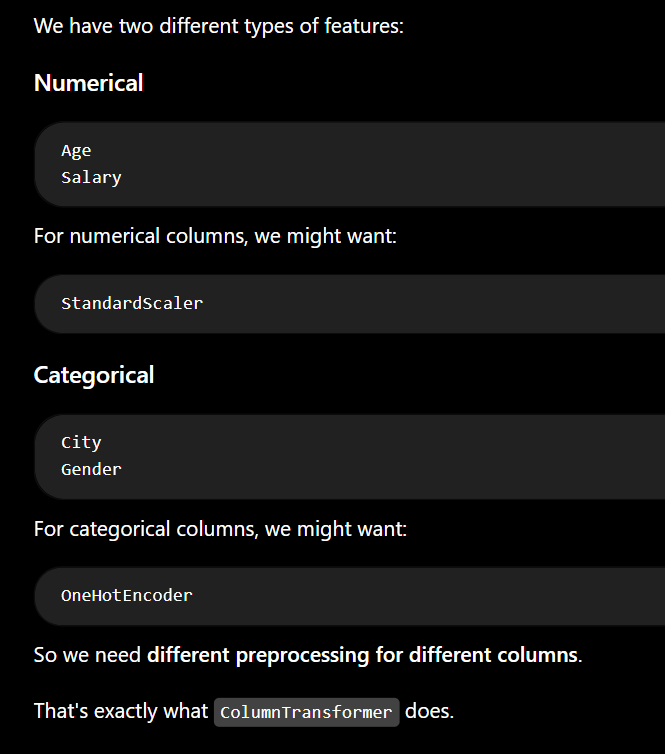

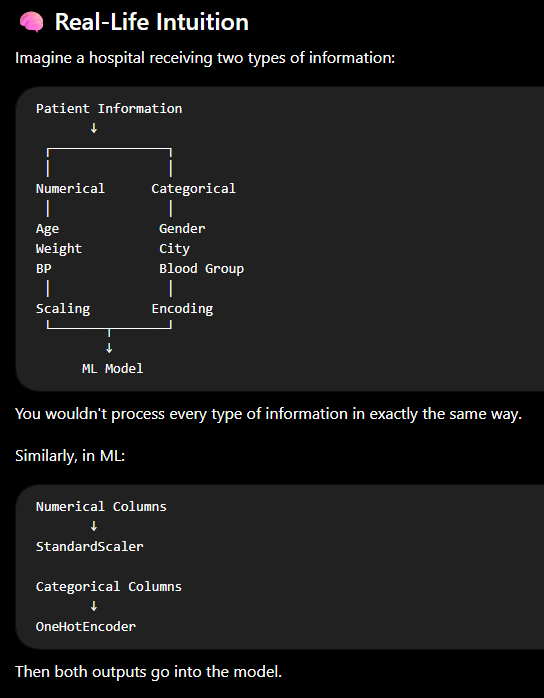
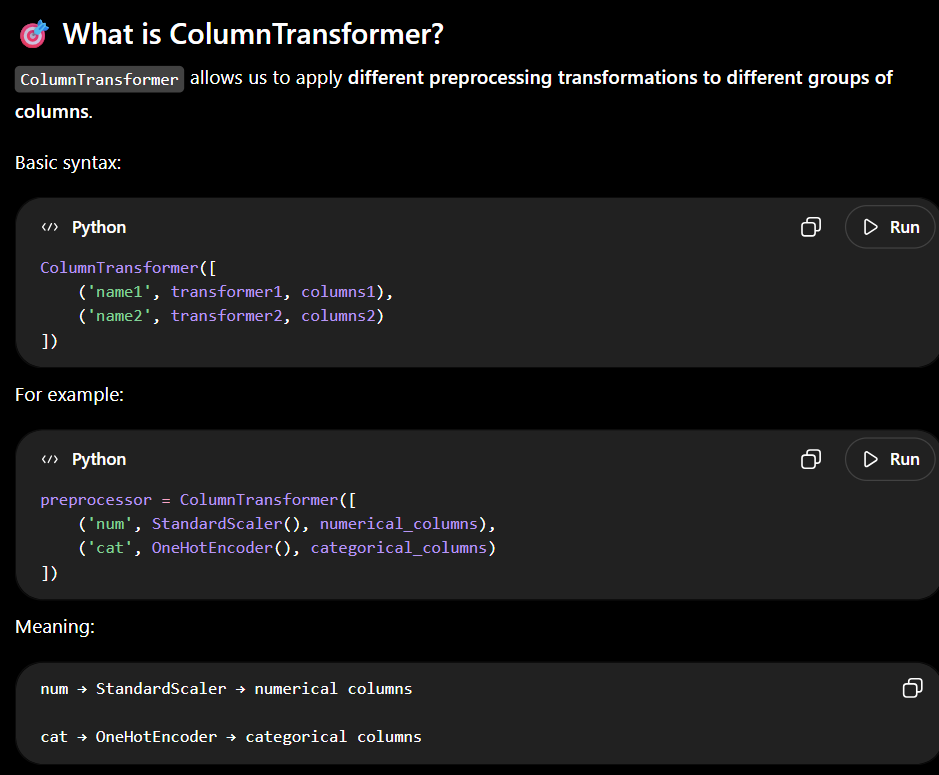

In [138]:
import pandas as pd
data = {
    'age': [25, 30, 35, 40, 28, 32, 45, 29, 38, 26],
    'salary': [40000, 50000, 60000, 80000, 45000,
               55000, 90000, 42000, 70000, 43000],
    'city': ['Delhi', 'Mumbai', 'Delhi', 'Bangalore',
             'Mumbai', 'Delhi', 'Bangalore', 'Delhi',
             'Mumbai', 'Bangalore'],
    'gender': ['Male', 'Female', 'Male', 'Female',
               'Male', 'Female', 'Male', 'Female',
               'Male', 'Male'],
    'purchased': [0, 1, 1, 1, 0, 1, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
df.head()

,age,salary,city,gender,purchased
0,25,40000,Delhi,Male,0
1,30,50000,Mumbai,Female,1
2,35,60000,Delhi,Male,1
3,40,80000,Bangalore,Female,1
4,28,45000,Mumbai,Male,0


In [171]:
X = df.drop('purchased', axis = 1)
# X = df[["age", "salary", "city", "gender"]]

In [172]:
X

,age,salary,city,gender
0,25,40000,Delhi,Male
1,30,50000,Mumbai,Female
2,35,60000,Delhi,Male
3,40,80000,Bangalore,Female
4,28,45000,Mumbai,Male
5,32,55000,Delhi,Female
6,45,90000,Bangalore,Male
7,29,42000,Delhi,Female
8,38,70000,Mumbai,Male
9,26,43000,Bangalore,Male


In [173]:
y = df['purchased']

In [174]:
y

0    0
1    1
2    1
3    1
4    0
5    1
6    1
7    0
8    1
9    0
Name: purchased, dtype: int64

In [175]:
cat_cols = df.select_dtypes(include = 'object')
cat_cols

,city,gender
0,Delhi,Male
1,Mumbai,Female
2,Delhi,Male
3,Bangalore,Female
4,Mumbai,Male
5,Delhi,Female
6,Bangalore,Male
7,Delhi,Female
8,Mumbai,Male
9,Bangalore,Male


In [176]:
num_cols = df.select_dtypes(include = ['int', 'float'])
num_cols

,age,salary,purchased
0,25,40000,0
1,30,50000,1
2,35,60000,1
3,40,80000,1
4,28,45000,0
5,32,55000,1
6,45,90000,1
7,29,42000,0
8,38,70000,1
9,26,43000,0


In [177]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [178]:
scaler = StandardScaler()
scaled = scaler.fit_transform(num_cols)
scaled

array([[-1.25610542, -1.06491749, -1.22474487],
       [-0.45090964, -0.45639321,  0.81649658],
       [ 0.35428614,  0.15213107,  0.81649658],
       [ 1.15948193,  1.36917962,  0.81649658],
       [-0.77298795, -0.76065535, -1.22474487],
       [-0.12883133, -0.15213107,  0.81649658],
       [ 1.96467771,  1.9777039 ,  0.81649658],
       [-0.6119488 , -0.94321263, -1.22474487],
       [ 0.83740361,  0.76065535,  0.81649658],
       [-1.09506626, -0.8823602 , -1.22474487]])

In [179]:
ohe = OneHotEncoder()
encoded = ohe.fit_transform(cat_cols)
encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20 stored elements and shape (10, 5)>

In [180]:
from sklearn.compose import  ColumnTransformer

In [181]:
preprocessor = ColumnTransformer([])

In [182]:
preprocessor = ColumnTransformer([
   ("Scaled", StandardScaler(), num_cols),
   ("Encoded", OneHotEncoder(handle_unknown = 'ignore'), cat_cols)
])

In [183]:
preprocessor

ColumnTransformer(transformers=[('Scaled', StandardScaler(),
                                    age  salary  purchased
0   25   40000          0
1   30   50000          1
2   35   60000          1
3   40   80000          1
4   28   45000          0
5   32   55000          1
6   45   90000          1
7   29   42000          0
8   38   70000          1
9   26   43000          0),
                                ('Encoded',
                                 OneHotEncoder(handle_unknown='ignore'),
                                         city  gender
0      Delhi    Male
1     Mumbai  Female
2      Delhi    Male
3  Bangalore  Female
4     Mumbai    Male
5      Delhi  Female
6  Bangalore    Male
7      Delhi  Female
8     Mumbai    Male
9  Bangalore    Male)])

In [184]:
from sklearn.linear_model import LogisticRegression


In [185]:
from sklearn.pipeline import Pipeline

In [186]:
pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('LogisticRegression', LogisticRegression())
])

In [187]:
pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Scaled', StandardScaler(),
                                                     age  salary  purchased
0   25   40000          0
1   30   50000          1
2   35   60000          1
3   40   80000          1
4   28   45000          0
5   32   55000          1
6   45   90000          1
7   29   42000          0
8   38   70000          1
9   26   43000          0),
                                                 ('Encoded',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                          city  gender
0      Delhi    Male
1     Mumbai  Female
2      Delhi    Male
3  Bangalore  Female
4     Mumbai    Male
5      Delhi  Female
6  Bangalore    Male
7      Delhi  Female
8     Mumbai    Male
9  Bangalore    Male)])),
                ('LogisticRegression', LogisticRegression())])

In [188]:
df.head()

,age,salary,city,gender,purchased
0,25,40000,Delhi,Male,0
1,30,50000,Mumbai,Female,1
2,35,60000,Delhi,Male,1
3,40,80000,Bangalore,Female,1
4,28,45000,Mumbai,Male,0


In [189]:
from sklearn.model_selection import train_test_split

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [191]:
pipeline.fit(X_train, y_train)

ValueError: No valid specification of the columns. Only a scalar, list or slice of all integers or all strings, or boolean mask is allowed

In [169]:
data = {
    'age': [25, 30, 35, 40, 28, 32, 45, 29, 38, 26],
    'salary': [40000, 50000, 60000, 80000, 45000,
               55000, 90000, 42000, 70000, 43000],
    'city': ['Delhi', 'Mumbai', 'Delhi', 'Bangalore',
             'Mumbai', 'Delhi', 'Bangalore', 'Delhi',
             'Mumbai', 'Bangalore'],
    'gender': ['Male', 'Female', 'Male', 'Female',
               'Male', 'Female', 'Male', 'Female',
               'Male', 'Male'],
    'purchased': [0, 1, 1, 1, 0, 1, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

In [170]:
X = df.drop('purchased', axis=1)
y = df['purchased']

In [192]:
numerical_columns = ['age', 'salary']

categorical_columns = ['city', 'gender']

In [193]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
])

In [194]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

In [195]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [196]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'salary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'gender'])])),
                ('model', LogisticRegression())])

In [198]:
y_pred = pipeline.predict(X_test)
y_pred

array([1, 0])

In [199]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred, y_test)

0.5